# TS-Guessing: evidence of possible dataset contamination

This analysis asks how much each evaluated model can reconstruct, how easily predictable
alternatives affect that result, and which questions deserve review. For each question,
every incorrect alternative is masked in turn; the model must reproduce its exact text,
with or without the exam name, edition and question number.

**Reconstruction is evidence to investigate, not a measured percentage of contaminated
questions.** A model can infer an alternative from context without prior exposure.
The primary metric averages normalized exact matches across distractors within each
question, then gives every complete question equal weight. Normalization applies Unicode
NFKC and collapses whitespace, preserving case, accents, numbers and punctuation.

Set `RUN_DIR` and optionally `ANALYSIS_MODELS` below. This notebook uses recorded responses
and exports the evidence behind its results. Questions remain in their original Portuguese.

In [1]:
from __future__ import annotations

import hashlib
import json
import sys
from html import escape
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

RUN_DIR = None  # Relative paths resolve from the repository root.
ANALYSIS_MODELS = None  # None selects every recorded model; otherwise use a list of names.
ANALYSIS_DIR = None  # None exports to RUN_DIR / "analysis".
BOOTSTRAP_REPLICATES = 2000
BOOTSTRAP_SEED = 42

cwd = Path.cwd().resolve()
REPO_ROOT = next((path for path in (cwd, *cwd.parents)
                  if (path / "pyproject.toml").exists() and (path / "ablations").exists()), None)
if REPO_ROOT is None:
    raise ValueError("Open this notebook from inside the mmlu-pt repository.")
STUDY_DIR = REPO_ROOT / "ablations/contamination/ts_guessing"
if str(STUDY_DIR) not in sys.path:
    sys.path.insert(0, str(STUDY_DIR))

from artifacts import ARTIFACT_VERSION, read_json, read_jsonl
from analysis_helpers import (
    CONDITIONS, METRICS, PRIMARY_METRIC, STATUSES, analyze_responses,
    build_question_review, load_model, predictability_summary, remember_matches,
    save_frame, summarize_questions, validate_tasks,
)

if RUN_DIR is None:
    available = sorted(path.parent for path in (STUDY_DIR / "output").glob("*/manifest.json")
                       if read_json(path).get("artifact_version") == ARTIFACT_VERSION)
    if len(available) != 1:
        raise ValueError(f"Set RUN_DIR explicitly. Available runs: {available}")
    RUN_DIR = available[0]
else:
    RUN_DIR = Path(RUN_DIR).expanduser()
    RUN_DIR = RUN_DIR if RUN_DIR.is_absolute() else REPO_ROOT / RUN_DIR
manifest = read_json(RUN_DIR / "manifest.json")
if manifest.get("artifact_version") != ARTIFACT_VERSION:
    raise ValueError(f"Expected artifact_version={ARTIFACT_VERSION}.")
ANALYSIS_DIR = RUN_DIR / "analysis" if ANALYSIS_DIR is None else Path(ANALYSIS_DIR).expanduser()
if not ANALYSIS_DIR.is_absolute():
    ANALYSIS_DIR = REPO_ROOT / ANALYSIS_DIR
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
if BOOTSTRAP_REPLICATES < 1:
    raise ValueError("BOOTSTRAP_REPLICATES must be positive.")

plt.rcParams.update({"font.size": 10, "axes.titlesize": 13, "axes.labelsize": 11,
                     "figure.dpi": 110, "savefig.dpi": 200})
CONDITION_LABELS = {"without_source": "Without source", "with_source": "With source"}


def show_table(frame):
    display(frame.style.hide(axis="index").set_properties(**{
        "font-size": "12px", "text-align": "left",
    }).set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("font-size", "12px")]},
        {"selector": "td, th", "props": [("padding", "5px 8px")]},
    ]))

## 1. Recorded data and coverage

Only the latest response for each model–task pair is used. Missing requests, context
overflow and request errors are kept separate from incorrect reconstruction. A question
contributes to a model's primary rate only when all its distractors completed in that
condition. The table in the next section reports this coverage for every model.

In [2]:
for filename, key in (("sample.jsonl", "sample_sha256"), ("tasks.jsonl", "tasks_sha256")):
    with (RUN_DIR / filename).open("rb") as stream:
        if hashlib.file_digest(stream, "sha256").hexdigest() != manifest[key]:
            raise ValueError(f"Artifact checksum mismatch: {filename}")
sample = pd.DataFrame(read_jsonl(RUN_DIR / "sample.jsonl"))
tasks = pd.DataFrame(read_jsonl(RUN_DIR / "tasks.jsonl")).drop(columns="prompt")
validate_tasks(sample, tasks, manifest)

all_specs = manifest["config"]["models"]
selected = ANALYSIS_MODELS if ANALYSIS_MODELS is not None else [spec["name"] for spec in all_specs]
unknown = set(selected) - {spec["name"] for spec in all_specs}
if isinstance(selected, str) or not selected or unknown or len(selected) != len(set(selected)):
    raise ValueError(f"Select a nonempty list of unique recorded model names; unknown: {sorted(unknown)}")
model_specs = [spec for spec in all_specs if spec["name"] in selected]
model_names = [spec["name"] for spec in model_specs]

metadata_rows, question_frames, coverage_frames, diagnostic_frames = [], [], [], []
matched_examples = {}
for index, spec in enumerate(model_specs):
    metadata, responses = load_model(RUN_DIR, spec, manifest)
    metadata_rows.append(metadata)
    grid, scored, model_questions = analyze_responses(tasks, responses, spec["name"])
    coverage = grid.groupby(["model", "condition", "status"]).size().unstack(fill_value=0)
    coverage = coverage.reindex(columns=STATUSES, fill_value=0).reset_index()
    coverage["expected"] = coverage[list(STATUSES)].sum(axis=1)
    coverage["completed_fraction"] = coverage.completed / coverage.expected
    coverage_frames.append(coverage)
    question_frames.append(model_questions)
    diagnostic_frames.append(predictability_summary(scored, spec["name"]))
    remember_matches(scored, matched_examples)
    save_frame(ANALYSIS_DIR, "task_scores", scored, append=index > 0)
    evidence = grid.merge(scored[["task_id", *METRICS]], on="task_id", how="left", validate="one_to_one")
    evidence = evidence.merge(sample[["question_id", "source_row_index"]], on="question_id", validate="many_to_one")
    save_frame(ANALYSIS_DIR, "question_evidence", evidence, jsonl=True, append=index > 0)
    del responses, grid, scored, evidence

models = pd.DataFrame(metadata_rows)
questions = pd.concat(question_frames, ignore_index=True)
coverage = pd.concat(coverage_frames, ignore_index=True)
predictability = pd.concat(diagnostic_frames, ignore_index=True)
del question_frames, coverage_frames, diagnostic_frames
save_frame(ANALYSIS_DIR, "model_metadata", models)
save_frame(ANALYSIS_DIR, "request_coverage", coverage)
save_frame(ANALYSIS_DIR, "question_scores_and_coverage", questions)
save_frame(ANALYSIS_DIR, "predictability_summary", predictability)

with (ANALYSIS_DIR / "question_catalog.jsonl").open("w", encoding="utf-8") as stream:
    for row in sample.to_dict("records"):
        record = {**row, "source": manifest["dataset"], "source_snapshot_sha256": manifest["snapshot_hash"],
                  "source_order_sha256": manifest["source_order_sha256"],
                  "source_record_sha256": row["question_id"].split(":")[0], "run_identity": manifest["identity"]}
        stream.write(json.dumps(record, ensure_ascii=False) + "\n")
panel = {
    "run_identity": manifest["identity"], "models": model_names,
    "families": models.groupby("family")["model"].apply(list).to_dict(),
    "metric": PRIMARY_METRIC, "conditions": list(CONDITIONS),
    "weighting": "equal conditions, equal checkpoints within family, equal families",
    "eligibility": "all masks, both conditions, every selected model completed",
    "bootstrap_replicates": BOOTSTRAP_REPLICATES, "bootstrap_seed": BOOTSTRAP_SEED,
}
(ANALYSIS_DIR / "panel.json").write_text(json.dumps(panel, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
expected_requests = len(tasks) * len(models)
completed_requests = int(coverage.completed.sum())
display(Markdown(
    f"**Snapshot:** {len(sample):,}/{manifest['population_size']:,} questions "
    f"({len(sample) / manifest['population_size']:.1%}), across {sample.exam.nunique()} exams. "
    f"**Panel:** {len(models)} models in {models.family.nunique()} families. "
    f"**Responses:** {completed_requests:,}/{expected_requests:,} completed "
    f"({completed_requests / expected_requests:.1%}); "
    f"{int(coverage.context_overflow.sum()):,} context overflows, "
    f"{int(coverage.request_error.sum()):,} request errors and "
    f"{int(coverage.not_run.sum()):,} missing. "
    f"**Recorded generation status:** {manifest['status']}."
))

**Snapshot:** 37,887/37,887 questions (100.0%), across 17 exams. **Panel:** 19 models in 5 families. **Responses:** 5,214,132/5,214,132 completed (100.0%); 0 context overflows, 0 request errors and 0 missing. **Recorded generation status:** completed.

## 2. How much can each model reconstruct?

Read one row at a time: the left panel shows reconstruction **without source information**,
and the right panel shows reconstruction **with source information**. Both use the same
percentage scale. Models are ordered from highest to lowest by the rate without source;
the percentage is printed beside each bar. These are **question-average reconstruction
rates**, not percentages of contaminated questions.

Thin lines mark pointwise 95% bootstrap intervals, resampling questions within exams with
the replicate count and seed set above; distractors stay together. For the full snapshot,
these describe sensitivity to question composition, rather than sampling error for that
finite dataset. Each bar uses the complete questions available for its model and condition.

The table reports complete-question coverage and the separately paired source effect:
**with source − without source**, in percentage points (pp). A label below 0.01% indicates
a small positive rate; missing estimates are marked explicitly.

In [3]:
summary, hint_effects = summarize_questions(
    questions, models, len(sample), BOOTSTRAP_REPLICATES, BOOTSTRAP_SEED,
)
save_frame(ANALYSIS_DIR, "overall_summary", summary)
save_frame(ANALYSIS_DIR, "paired_source_hint_effects", hint_effects)

rows = []
for model in model_names:
    rates = summary[summary.model.eq(model)].set_index("condition")
    effect = hint_effects[hint_effects.model.eq(model)].iloc[0]
    row = {"Model": model}
    for condition in CONDITIONS:
        result = rates.loc[condition]
        row[CONDITION_LABELS[condition]] = "—" if pd.isna(result.sample_em) else f"{result.sample_em:.2%}"
        row[f"Coverage: {CONDITION_LABELS[condition].lower()}"] = (
            f"{int(result.complete_questions):,} ({result.question_coverage:.1%})"
        )
    row["Source effect, pp [95% interval]"] = (
        "—" if pd.isna(effect.sample_difference) else
        f"{100 * effect.sample_difference:+.2f} [{100 * effect.sample_lower:+.2f}, {100 * effect.sample_upper:+.2f}]"
    )
    row["Paired questions"] = f"{int(effect.shared_questions):,}"
    rows.append(row)
primary_table = pd.DataFrame(rows)
show_table(primary_table[["Model", "Without source", "With source", "Coverage: without source",
                          "Coverage: with source", "Source effect, pp [95% interval]", "Paired questions"]])

Model,Without source,With source,Coverage: without source,Coverage: with source,"Source effect, pp [95% interval]",Paired questions
qwen3.5-0.8b,0.21%,0.11%,"37,887 (100.0%)","37,887 (100.0%)","-0.10 [-0.13, -0.07]","37,887"
qwen3.5-2b,0.80%,0.75%,"37,887 (100.0%)","37,887 (100.0%)","-0.05 [-0.10, -0.01]","37,887"
qwen3.5-4b,3.44%,5.12%,"37,887 (100.0%)","37,887 (100.0%)","+1.68 [+1.58, +1.77]","37,887"
qwen3.5-9b,5.18%,7.84%,"37,887 (100.0%)","37,887 (100.0%)","+2.66 [+2.55, +2.77]","37,887"
qwen3.5-27b,11.11%,12.15%,"37,887 (100.0%)","37,887 (100.0%)","+1.04 [+0.96, +1.12]","37,887"
qwen3.5-35b-a3b,6.64%,8.53%,"37,887 (100.0%)","37,887 (100.0%)","+1.90 [+1.80, +2.00]","37,887"
llama-3.2-1b,0.08%,0.04%,"37,887 (100.0%)","37,887 (100.0%)","-0.04 [-0.05, -0.02]","37,887"
llama-3.2-3b,0.31%,0.37%,"37,887 (100.0%)","37,887 (100.0%)","+0.06 [+0.03, +0.09]","37,887"
llama-3.1-8b,1.66%,1.41%,"37,887 (100.0%)","37,887 (100.0%)","-0.25 [-0.32, -0.18]","37,887"
tucano2-0.5b,0.00%,0.00%,"37,887 (100.0%)","37,887 (100.0%)","+0.00 [-0.00, +0.01]","37,887"


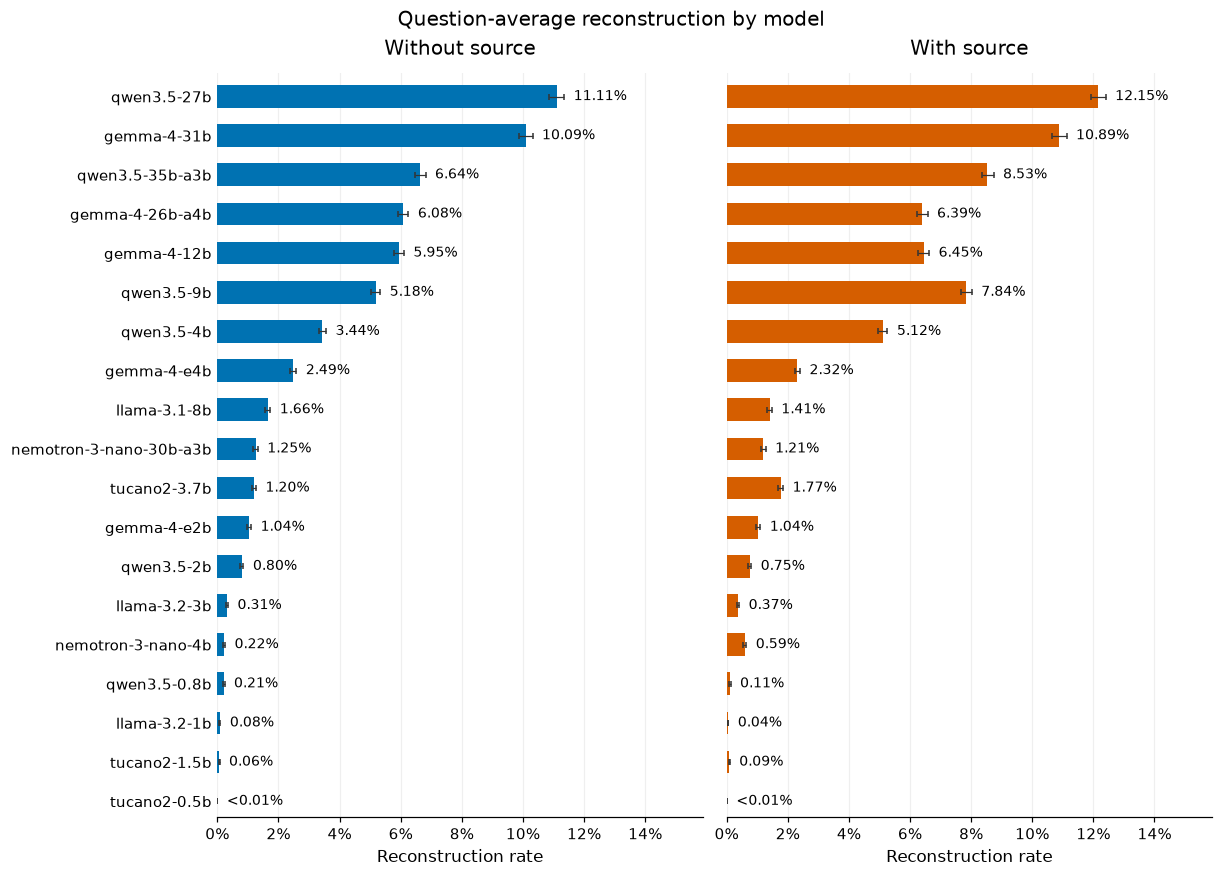

In [2]:
if summary.sample_em.notna().any():
    ordering = summary.pivot(index="model", columns="condition", values="sample_em").reindex(model_names)
    display_order = ordering.sort_values(list(CONDITIONS), ascending=False, na_position="last").index.tolist()
    positions = np.arange(len(display_order))
    fig, axes = plt.subplots(1, 2, figsize=(11, max(4, len(display_order) * 0.34 + 1.4)),
                             sharex=True, sharey=True, layout="constrained")
    upper = summary.sample_upper.max()
    label_gap = max(0.0002, upper * 0.025)
    limit = max(0.01, upper * 1.28)
    for ax, condition, color in zip(axes, CONDITIONS, ("#0072B2", "#D55E00")):
        table = summary[summary.condition.eq(condition)].set_index("model").reindex(display_order)
        valid = table.sample_em.notna()
        observed = table[valid]
        errors = np.maximum(0, np.vstack([observed.sample_em - observed.sample_lower,
                                         observed.sample_upper - observed.sample_em]))
        ax.barh(positions[valid.to_numpy()], observed.sample_em, height=0.58, color=color,
                xerr=errors, error_kw={"ecolor": "#333333", "elinewidth": 0.8, "capsize": 2})
        for position, row in zip(positions, table.itertuples()):
            if pd.isna(row.sample_em):
                ax.text(label_gap, position, "No complete questions", va="center", fontsize=8, color="#666666")
                continue
            label = "<0.01%" if 0 < row.sample_em < 0.0001 else f"{row.sample_em:.2%}"
            ax.text(row.sample_upper + label_gap, position, label, va="center", fontsize=9)
        ax.set_title(CONDITION_LABELS[condition], pad=12)
        ax.set_xlim(0, limit)
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0 if upper >= 0.1 else 1))
        ax.set_xlabel("Reconstruction rate")
        ax.grid(axis="x", alpha=0.2)
        ax.set_axisbelow(True)
        ax.tick_params(axis="y", length=0)
        ax.spines[["top", "right", "left"]].set_visible(False)
    axes[0].set_yticks(positions, display_order)
    axes[0].set_ylim(len(display_order) - 0.6, -0.6)
    fig.suptitle("Question-average reconstruction by model", fontsize=13)
    for extension in ("png", "pdf"):
        fig.savefig(ANALYSIS_DIR / f"reconstruction_by_model.{extension}", bbox_inches="tight")
    plt.show()
    plt.close(fig)
else:
    display(Markdown("No model has a complete question. Rates and source effects are unavailable; see coverage and exported evidence."))

## 3. How much could predictability explain?

Compare all completed distractors with a conservative subset: **at least eight words,
not purely numeric, and absent from the visible question and alternatives**. Visible
context can contain duplicate alternatives or alternative text retained in the question
stem. The table
shows exact-match rates and the number of completed masks in parentheses.

These are **mask-level averages**, unlike the primary question-average result. The subset
changes the questions and targets being measured, so its rate is a diagnostic, not a
corrected contamination estimate. Remaining targets can still be inferred. “— (0)” means
no observations, not a zero reconstruction rate.

In [5]:
rows = []
for model in model_names:
    results = predictability[predictability.model.eq(model)].set_index("condition")
    row = {("", "Model"): model}
    for condition in CONDITIONS:
        result = results.loc[condition]
        for label, metric, denominator in (
            ("All masks", "mean_em", "completed_masks"),
            ("Less predictable", "less_predictable_em", "less_predictable_masks"),
        ):
            rate, count = result[metric], int(result[denominator])
            row[(CONDITION_LABELS[condition], label)] = (
                f"— ({count:,})" if pd.isna(rate) else f"{rate:.2%} ({count:,})"
            )
    rows.append(row)
diagnostic_table = pd.DataFrame(rows)
diagnostic_table.columns = pd.MultiIndex.from_tuples(diagnostic_table.columns)
show_table(diagnostic_table)

## 4. Which questions deserve review?

The consensus score averages distractors within a question, then the two conditions per
model, checkpoints within each family, and finally families with equal weights. Every
selected model must have completed every mask in both conditions for a question to be
ranked. Missing results never become zero scores. Ties are ordered by question ID.

Below are up to three questions with the highest positive scores. Each includes one exact
reconstruction, preferring the longest matched alternative and then the condition without
source. The score is a review priority, not a contamination probability; the predictability
flags are essential to interpretation. The complete ranking and evidence are exported.

In [6]:
per_model, family_scores, review, ranking = build_question_review(questions, models, sample, tasks)
save_frame(ANALYSIS_DIR, "question_model_scores", per_model)
save_frame(ANALYSIS_DIR, "question_family_scores", family_scores)
save_frame(ANALYSIS_DIR, "question_review_coverage", review, jsonl=True)
save_frame(ANALYSIS_DIR, "question_ranking", ranking, jsonl=True)
top_questions = ranking[ranking.consensus_score.gt(0)].head(3)
display(Markdown(
    f"**Eligible for ranking:** {len(ranking):,}/{len(sample):,} questions; "
    f"{models.family.nunique()} equally weighted families. "
    "Full details: `question_ranking.csv`, `question_catalog.jsonl` and `question_evidence.jsonl` "
    "in the configured analysis directory."
))

**Eligible for ranking:** 37,887/37,887 questions; 5 equally weighted families. Full details: `question_ranking.csv`, `question_catalog.jsonl` and `question_evidence.jsonl` in the configured analysis directory.

In [7]:
example_records = []
catalog = sample.set_index("question_id")
for result in top_questions.to_dict("records"):
    question = catalog.loc[result["question_id"]]
    match = matched_examples[result["question_id"]]
    example_records.append({**result, "question": question.question, "match": match})
    display(HTML(
        f"<h4>{int(result['rank'])}. {escape(str(result['exam']))} · "
        f"{escape(str(result['exam_edition']))} · question {escape(str(result['num']))} "
        f"— consensus {result['consensus_score']:.1%}</h4>"
        f"<p>Distractor diagnostics: {result['short_targets']}/{result['distractors']} short (1–3 words); "
        f"{result['numeric_targets']}/{result['distractors']} numeric; "
        f"<strong>{result['targets_in_context']}/{result['distractors']} present in visible context.</strong></p>"
        f"<div style='white-space:pre-wrap;overflow-wrap:anywhere'>{escape(str(question.question))}</div>"
        f"<p><strong>Reconstructed distractor {escape(match['mask_label'])}:</strong> "
        f"{escape(match['target'])}</p>"
        f"<p>Exact match by <code>{escape(match['model'])}</code> "
        f"({CONDITION_LABELS[match['condition']].lower()}); {match['target_words']} words; "
        f"numeric: {'yes' if match['target_numeric'] else 'no'}; "
        f"present in visible context: <strong>{'yes' if match['target_in_context'] else 'no'}</strong>.</p>"
        f"<details><summary>Recorded model response and question ID</summary>"
        f"<p style='white-space:pre-wrap;overflow-wrap:anywhere'>{escape(match['text'])}</p>"
        f"<code>{escape(result['question_id'])}</code></details>"
    ))
if top_questions.empty:
    reason = "No questions meet complete-panel eligibility." if ranking.empty else "No eligible question has an exact reconstruction."
    display(Markdown(reason + " The coverage and evidence exports retain all questions."))
with (ANALYSIS_DIR / "top_question_examples.jsonl").open("w", encoding="utf-8") as stream:
    for record in example_records:
        stream.write(json.dumps(record, ensure_ascii=False) + "\n")

## 5. What do these results support?

The following findings are generated from the loaded panel. They describe reconstruction
in this dataset revision. Source hints can change retrieval or instruction following;
differences between models also reflect architecture, language specialization and training.
Without exposure labels or a controlled contamination experiment, these observations
cannot establish contamination prevalence or a detector's precision and recall.

In [8]:
findings = [
    f"The analysis covers {len(sample):,}/{manifest['population_size']:,} recorded questions "
    f"and {len(models)} models; {completed_requests / expected_requests:.1%} of requests completed.",
]
for condition in CONDITIONS:
    observed = summary[summary.condition.eq(condition)].dropna(subset=["sample_em"])
    if observed.empty:
        findings.append(f"{CONDITION_LABELS[condition]}: no complete-question estimate is available.")
        continue
    highest = observed.loc[observed.sample_em.idxmax()]
    findings.append(
        f"{CONDITION_LABELS[condition]}: question-average reconstruction ranges from "
        f"{observed.sample_em.min():.2%} to {highest.sample_em:.2%}; "
        f"the highest observed rate is {highest.model} ({int(highest.complete_questions):,} complete questions)."
    )
paired = hint_effects.dropna(subset=["sample_difference"])
if not paired.empty:
    findings.append(
        f"On paired complete questions, the source effect ranges from "
        f"{100 * paired.sample_difference.min():+.2f} to {100 * paired.sample_difference.max():+.2f} pp "
        f"across {len(paired)} models. This is not an estimate of training exposure."
    )
restricted = predictability.dropna(subset=["less_predictable_em"])
if not restricted.empty:
    highest = restricted.loc[restricted.less_predictable_em.idxmax()]
    findings.append(
        f"For long, nonnumeric distractors absent from context, the highest observed mask-level "
        f"rate is {highest.less_predictable_em:.2%} ({highest.model}, "
        f"{CONDITION_LABELS[highest.condition].lower()}, {int(highest.less_predictable_masks):,} masks). "
        "This restricted rate is descriptive and uses a different denominator."
    )
if not top_questions.empty:
    contextual = int(top_questions.targets_in_context.eq(top_questions.distractors).sum())
    findings.append(
        f"{contextual}/{len(top_questions)} displayed review questions have every distractor already "
        "present in visible context. Inspect these flags before interpreting their consensus scores."
    )
if completed_requests < expected_requests:
    findings.append("Coverage is incomplete: rates use available complete questions, source effects use paired intersections, and ranking requires the complete selected panel.")
findings.append("The results support targeted review of possible contamination, without a binary verdict or a calibrated percentage of contaminated questions.")
report = "\n\n".join(findings)
(ANALYSIS_DIR / "findings.md").write_text(
    f"# TS-Guessing findings\n\nRun: {RUN_DIR.name}\n\n" + report + "\n", encoding="utf-8",
)
display(Markdown(report))

The analysis covers 37,887/37,887 recorded questions and 19 models; 100.0% of requests completed.

Without source: question-average reconstruction ranges from 0.00% to 11.11%; the highest observed rate is qwen3.5-27b (37,887 complete questions).

With source: question-average reconstruction ranges from 0.00% to 12.15%; the highest observed rate is qwen3.5-27b (37,887 complete questions).

On paired complete questions, the source effect ranges from -0.25 to +2.66 pp across 19 models. This is not an estimate of training exposure.

For long, nonnumeric distractors absent from context, the highest observed mask-level rate is 7.00% (qwen3.5-27b, with source, 69,599 masks). This restricted rate is descriptive and uses a different denominator.

3/3 displayed review questions have every distractor already present in visible context. Inspect these flags before interpreting their consensus scores.

The results support targeted review of possible contamination, without a binary verdict or a calibrated percentage of contaminated questions.